## Testing some Bias Mapping

from methods: https://python-cmethods.readthedocs.io/en/stable/methods.html

In [29]:
# setup imports
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parents[1]  # pas aan als notebook dieper/dichter zit
sys.path.append(str(PROJECT_ROOT))

import ewatercycle.forcing
import matplotlib.pyplot as plt
import xarray as xr
from ewatercycle.observation.grdc import get_grdc_data

from src.constants import DEFAULT_CMIP6_MODELS, SSP_SCENARIOS
from src.forcing import load_lumped_forcing_data, plot_lumped_ERA5_forcing
from src.paths import GRDC

MPI-ESM1-2-HR
ssp245


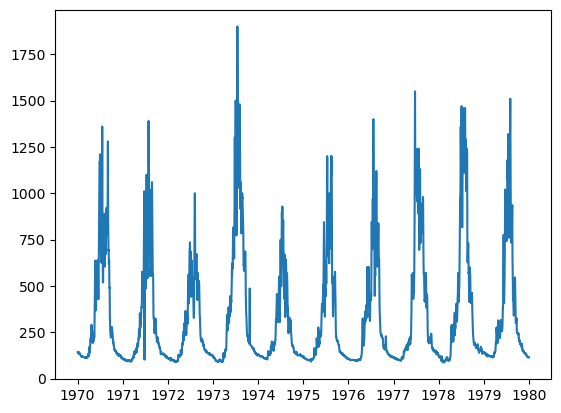

In [20]:
shape_name = "Garm_GRDC"
grdc_start_date = "1970-01-02T00:00Z"
grdc_end_date = "1979-12-31T00:00Z"
climate_historical_start_date = "1970-01-01T00:00Z"
climate_historical_end_date = "1979-12-31T00:00Z"
climate_historical_start_date_validation = "1980-01-01T00:00Z"
climate_historical_end_date_validation = "1989-12-31T00:00Z"

climate_future_start_date = "2070-01-01T00:00Z"
climate_future_end_date = "2079-12-31T00:00Z"

grdc_station = get_grdc_data(2517920, grdc_start_date, grdc_end_date, data_home=GRDC / "Daily")

plt.plot(grdc_station["streamflow"]["time"], grdc_station["streamflow"], label="Observed")

print(DEFAULT_CMIP6_MODELS["historical"])
print(SSP_SCENARIOS[1])

In [21]:
# # forcing_ERA5 = generate_lumped_ERA5_forcing(shape_name, start=climate_historical_start_date,end=climate_historical_end_date)
# # forcing_CMIP_historical = generate_lumped_CMIP_historical_forcing(shape_name, start=climate_historical_start_date, end=climate_historical_end_date, model=DEFAULT_CMIP6_MODELS['historical'])

# forcing_ERA5_validation = generate_lumped_ERA5_forcing(shape_name, start=climate_historical_start_date_validation,end=climate_historical_end_date_validation)
# forcing_CMIP_historical_validation = generate_lumped_CMIP_historical_forcing(shape_name, start=climate_historical_start_date_validation, end=climate_historical_end_date_validation, model=DEFAULT_CMIP6_MODELS['historical'])


# #forcing_CMIP_future = generate_lumped_CMIP_future_forcing(shape_name, start=climate_future_start_date, end=climate_future_end_date, model=DEFAULT_CMIP6_MODELS['historical'],ssp=SSP_SCENARIOS[1])

In [22]:
load_cmip_hist_calibrate = "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/forcing/output/CMIP_HIST/Garm_GRDC/1970-1979/work/diagnostic/script"
load_cmip_hist_validate = "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/forcing/output/CMIP_HIST/Garm_GRDC/1980-1989/work/diagnostic/script"
load_cmip_fut = "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/forcing/output/CMIP_FUT/MPI-ESM1-2-HR/ssp245/Garm_GRDC/2070-2079/work/diagnostic/script"

forcing_CMIP_hist_calibrate = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(
    directory=load_cmip_hist_calibrate
)
forcing_CMIP_hist_validate = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(
    directory=load_cmip_hist_validate
)
forcing_ERA5_calibrate = load_lumped_forcing_data(shape_name, "ERA5", "1970-1979")
forcing_ERA5_validate = load_lumped_forcing_data(shape_name, "ERA5", "1980-1989")

forcing_CMIP_future = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(
    directory=load_cmip_fut
)

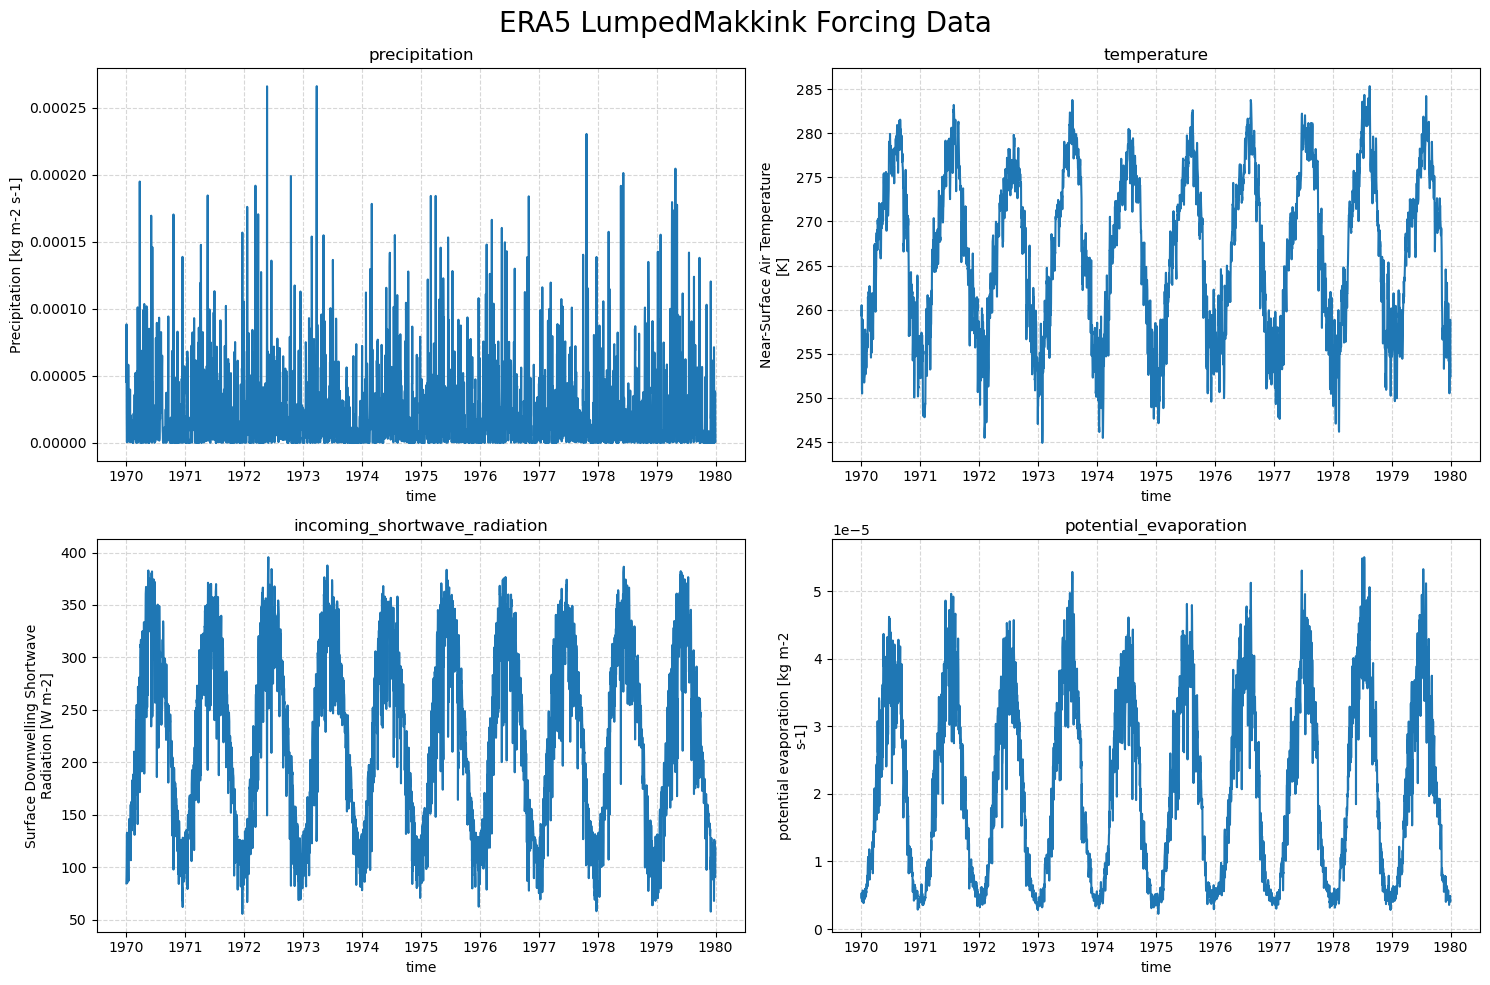

In [91]:
plot_lumped_ERA5_forcing(forcing_ERA5_calibrate)
# plot_lumped_ERA5_forcing(forcing_ERA5_validate)
# plot_lumped_ERA5_forcing(forcing_CMIP_hist_calibrate)
# plot_lumped_ERA5_forcing(forcing_CMIP_hist_validate)
# plot_lumped_ERA5_forcing(forcing_CMIP_future)

In [49]:
from pathlib import Path


def forcing_to_xarray(forcing):
    """
    Convert a LumpedMakkinkForcing (loaded or generated)
    into a single xarray.Dataset
    """

    datasets = []

    # Case 1: Loaded LumpedMakkinkForcing (CMIP, ERA5 via load)
    if hasattr(forcing, "filenames") and hasattr(forcing, "directory"):
        base_dir = Path(forcing.directory)

        for var, fname in forcing.filenames.items():
            path = base_dir / fname
            ds = xr.open_dataset(path, engine="netcdf4")
            datasets.append(ds)

    # Case 2: Dict-like forcing (from generate or custom loaders)
    elif isinstance(forcing, dict):
        for _, path in forcing.items():
            path = Path(path)
            if path.suffix == ".nc":
                ds = xr.open_dataset(path, engine="netcdf4")
                datasets.append(ds)

    else:
        raise TypeError(f"Unsupported forcing type: {type(forcing)}")

    return xr.merge(datasets)


def normalize_time_to_day(ds):
    """
    Drop sub-daily time information and align all variables
    to daily timestamps at 00:00.
    """
    ds = ds.copy()
    ds["time"] = ds["time"].dt.floor("D")
    return ds


def collapse_daily_duplicates(ds):
    return ds.groupby("time").mean(skipna=True)

In [50]:
ds_CMIP_hist_calibrate = forcing_to_xarray(forcing_CMIP_hist_calibrate)
ds_CMIP_hist_validate = forcing_to_xarray(forcing_CMIP_hist_validate)

ds_ERA5_calibrate = forcing_to_xarray(forcing_ERA5_calibrate)
ds_ERA5_validate = forcing_to_xarray(forcing_ERA5_validate)

ds_CMIP_future = forcing_to_xarray(forcing_CMIP_future)

In [ ]:
ds_CMIP_hist_calibrate = normalize_time_to_day(ds_CMIP_hist_calibrate)
ds_CMIP_hist_validate = normalize_time_to_day(ds_CMIP_hist_validate)

ds_ERA5_calibrate = normalize_time_to_day(ds_ERA5_calibrate)
ds_ERA5_validate = normalize_time_to_day(ds_ERA5_validate)

ds_CMIP_future = normalize_time_to_day(ds_CMIP_future)


ds_ERA5_calibrate = collapse_daily_duplicates(ds_ERA5_calibrate)
ds_ERA5_validate = collapse_daily_duplicates(ds_ERA5_validate)

ds_CMIP_hist_calibrate = collapse_daily_duplicates(ds_CMIP_hist_calibrate)
ds_CMIP_hist_validate = collapse_daily_duplicates(ds_CMIP_hist_validate)
ds_CMIP_future = collapse_daily_duplicates(ds_CMIP_future)

In [57]:
obsh = ds_ERA5_calibrate.copy()
simh = ds_CMIP_hist_calibrate.copy()
simp = ds_CMIP_future.copy()

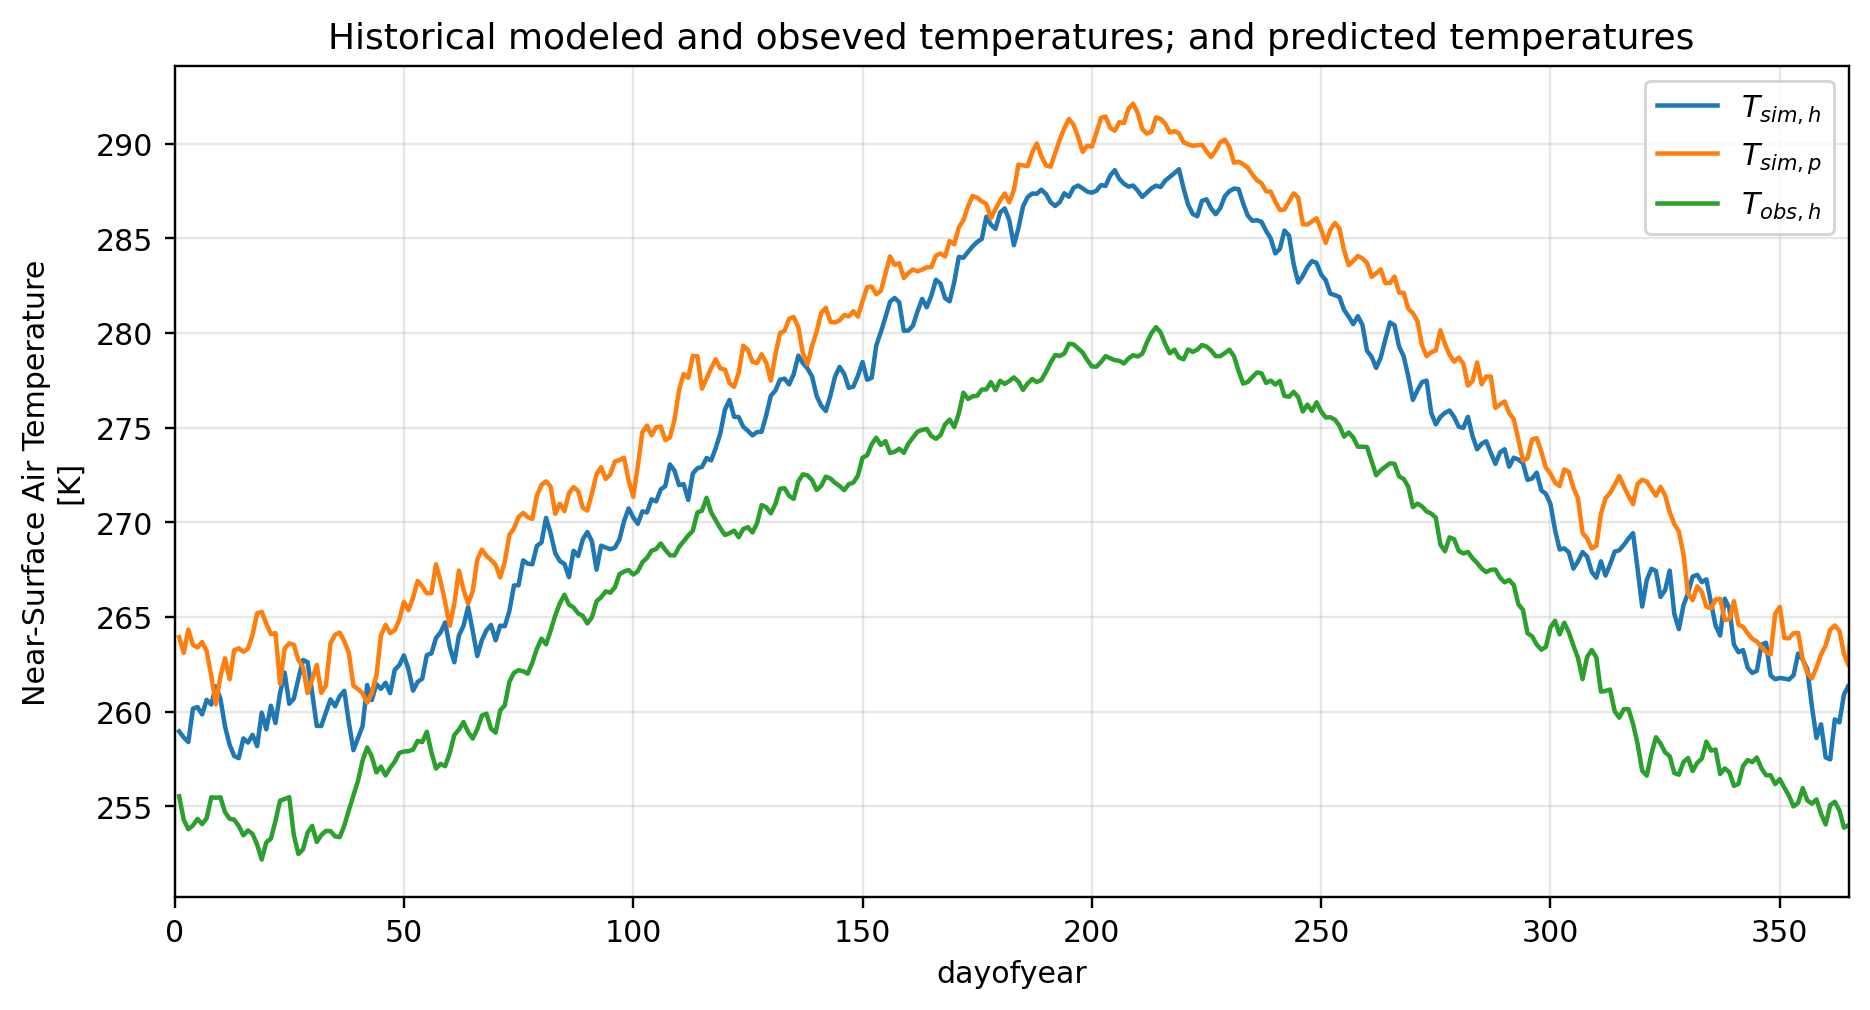

In [58]:
plt.figure(figsize=(10, 5), dpi=216)
simh["tas"].groupby("time.dayofyear").mean(...).plot(label="$T_{sim,h}$")
simp["tas"].groupby("time.dayofyear").mean(...).plot(label="$T_{sim,p}$")
obsh["tas"].groupby("time.dayofyear").mean(...).plot(label="$T_{obs,h}$")
plt.title("Historical modeled and obseved temperatures; and predicted temperatures")
plt.xlim(0, 365)
plt.gca().grid(alpha=0.3)
plt.legend()

In [55]:
from cmethods import adjust

In [59]:
# to adjust a 3d dataset
qdm_result = adjust(
    method="quantile_delta_mapping",
    obs=obsh["tas"],
    simh=simh["tas"],
    simp=simp["tas"],
    n_quantiles=1000,
    kind="+",  # to calculate the relative rather than the absolute change, "*" can be used instead of "+" (this is prefered when adjusting precipitation)
)

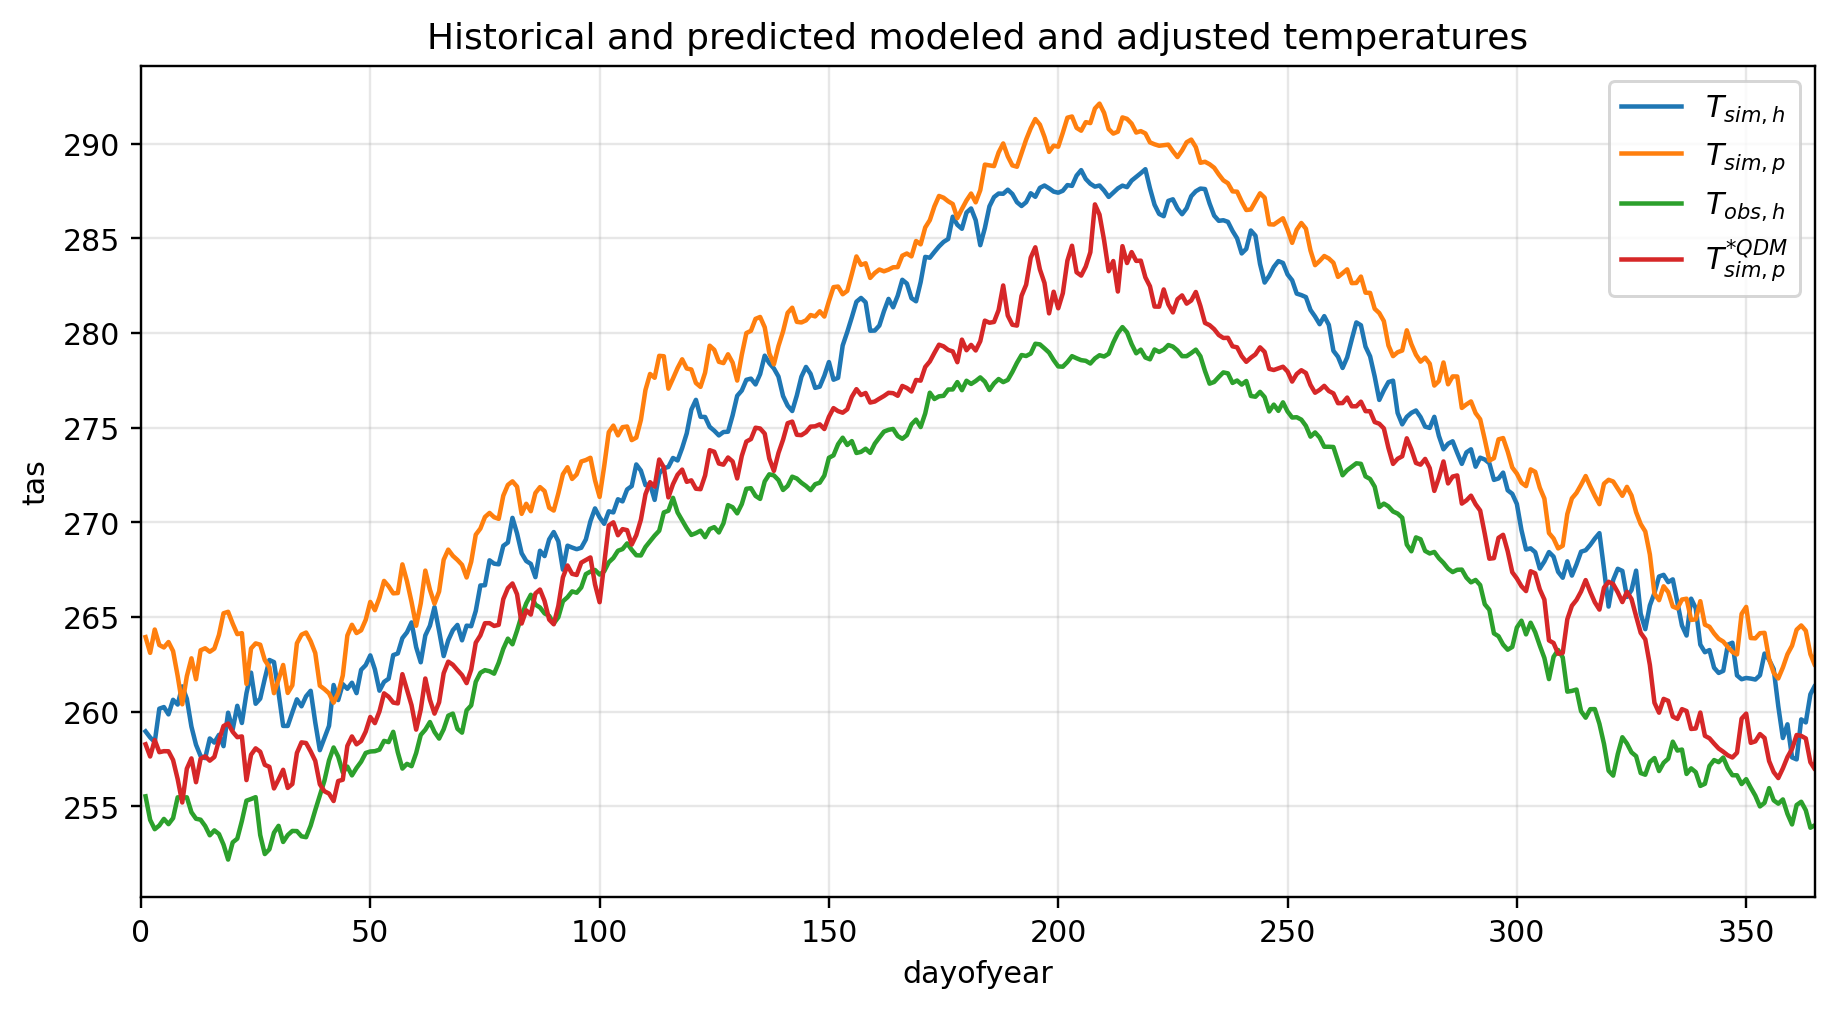

In [62]:
plt.figure(figsize=(10, 5), dpi=216)
simh["tas"].groupby("time.dayofyear").mean(...).plot(label="$T_{sim,h}$")
simp["tas"].groupby("time.dayofyear").mean(...).plot(label="$T_{sim,p}$")
obsh["tas"].groupby("time.dayofyear").mean(...).plot(label="$T_{obs,h}$")
qdm_result.groupby("time.dayofyear").mean(...).tas.plot(label="$T^{*QDM}_{sim,p}$")
plt.title("Historical and predicted modeled and adjusted temperatures")
plt.xlim(0, 365)
plt.gca().grid(alpha=0.3)
plt.legend()

In [63]:
ls_result = adjust(
    method="linear_scaling",
    obs=obsh["tas"],
    simh=simh["tas"],
    simp=simp["tas"],
    group="time.month",
    kind="+",
)

In [64]:
vs_result = adjust(
    method="variance_scaling",
    obs=obsh["tas"],
    simh=simh["tas"],
    simp=simp["tas"],
    group="time.month",
    kind="+",
)

In [65]:
dm_result = adjust(
    method="delta_method",
    obs=obsh["tas"],
    simh=simh["tas"],
    simp=simp["tas"],
    group="time.month",
    kind="+",
)

In [71]:
obsh["tas"]

<xarray.DataArray 'tas' (time: 3652)> Size: 15kB
array([259.3538 , 260.5034 , 255.45203, ..., 258.85544, 255.14973,
       252.47646], dtype=float32)
Coordinates:
    lat      float64 8B 39.25
    lon      float64 8B 72.0
    height   float64 8B 2.0
  * time     (time) datetime64[ns] 29kB 1970-01-01 1970-01-02 ... 1979-12-31
Attributes:
    standard_name:  air_temperature
    long_name:      Near-Surface Air Temperature
    units:          K
    cell_methods:   day_of_year: year: mean latitude: longitude: mean

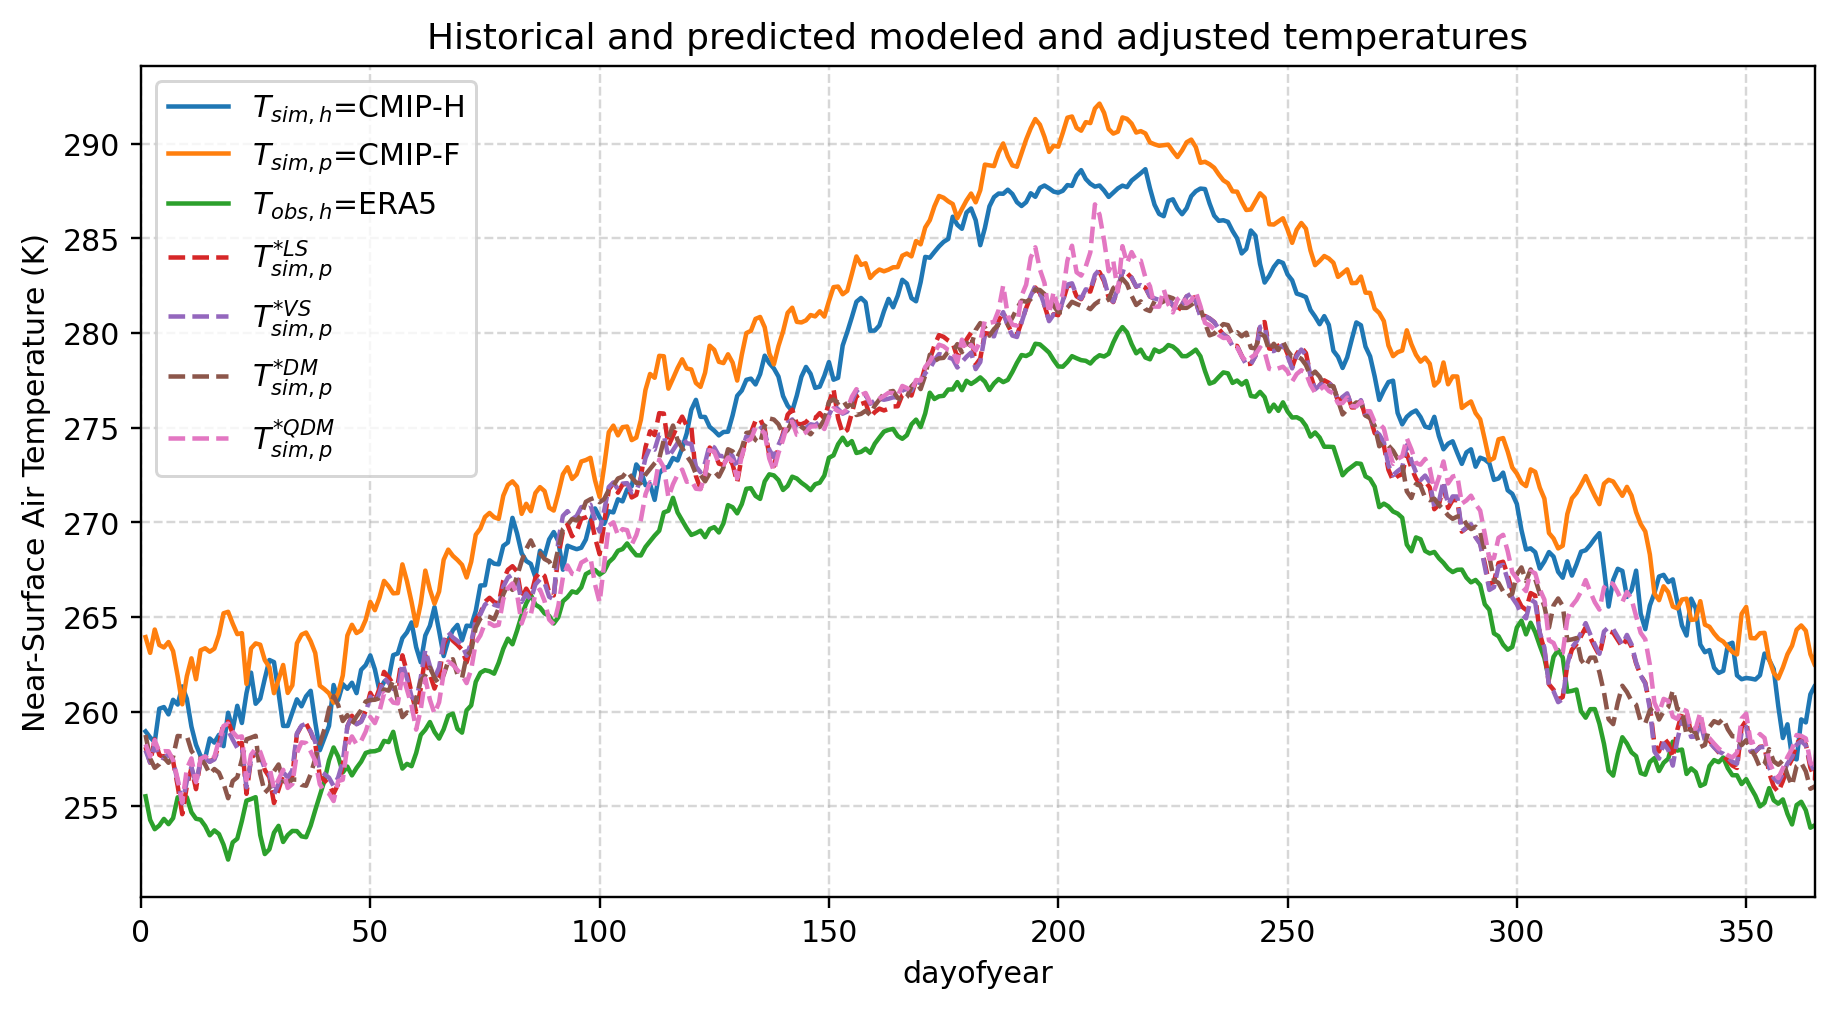

In [ ]:
plt.figure(figsize=(10, 5), dpi=216)
simh["tas"].groupby("time.dayofyear").mean(...).plot(label="$T_{sim,h}$=CMIP-H")  # = CMIP-hist")
simp["tas"].groupby("time.dayofyear").mean(...).plot(label="$T_{sim,p}$=CMIP-F")  # = CMIP6-fut")
obsh["tas"].groupby("time.dayofyear").mean(...).plot(label="$T_{obs,h}$=ERA5")  # = ERA5")
ls_result.groupby("time.dayofyear").mean(...).tas.plot(linestyle="--", label="$T^{*LS}_{sim,p}$")
vs_result.groupby("time.dayofyear").mean(...).tas.plot(linestyle="--", label="$T^{*VS}_{sim,p}$")
dm_result.groupby("time.dayofyear").mean(...).tas.plot(linestyle="--", label="$T^{*DM}_{sim,p}$")
qdm_result.groupby("time.dayofyear").mean(...).tas.plot(linestyle="--", label="$T^{*QDM}_{sim,p}$")
plt.title("Historical and predicted modeled and adjusted temperatures")
plt.xlim(0, 365)
plt.gca().grid(linestyle="--", alpha=0.5)
plt.ylabel(f"{obsh['tas'].long_name} ({obsh['tas'].units})")
plt.legend()